In [59]:
import pandas as pd
df = pd.read_csv('merged_financial_data_news.csv')
print('CSV file loaded successfully into DataFrame named `df`.')
print(df.head())

CSV file loaded successfully into DataFrame named `df`.
         Date      Ticker     Open     High      Low    Close  Adj Close  \
0  2023-01-02    adanient  3870.00  3874.00  3822.55  3841.20    3835.94   
1  2023-01-02  adaniports   823.00   826.75   816.30   822.30     809.38   
2  2023-01-02  apollohosp  4488.00  4516.70  4446.00  4454.35    4411.58   
3  2023-01-02  asianpaint  3087.90  3087.90  3021.00  3047.25    2955.81   
4  2023-01-02    axisbank   932.25   945.00   931.80   941.60     939.11   

    Volume        date                                       cleaned_news  \
0   923051  2023-01-02  indian equity index ended monday session green...   
1  2042294  2023-01-02  indian equity index ended monday session green...   
2   246577  2023-01-02  indian equity index ended monday session green...   
3  1015990  2023-01-02  indian equity index ended monday session green...   
4  3498198  2023-01-02  indian equity index ended monday session green...   

   cleaned_news_len  neg

In [60]:
from sklearn.preprocessing import MinMaxScaler

# Enumerate the 'Ticker' column
df['ticker_enumerated'], unique_tickers = pd.factorize(df['Ticker'])

# Scale the enumerated 'Ticker' values between 0 and 1
scaler = MinMaxScaler()
df['ticker_scaled'] = scaler.fit_transform(df[['ticker_enumerated']])

print("Enumerated Ticker values and scaled values created successfully.")
print(df[['Ticker', 'ticker_enumerated', 'ticker_scaled']].head())

Enumerated Ticker values and scaled values created successfully.
       Ticker  ticker_enumerated  ticker_scaled
0    adanient                  0       0.000000
1  adaniports                  1       0.020408
2  apollohosp                  2       0.040816
3  asianpaint                  3       0.061224
4    axisbank                  4       0.081633


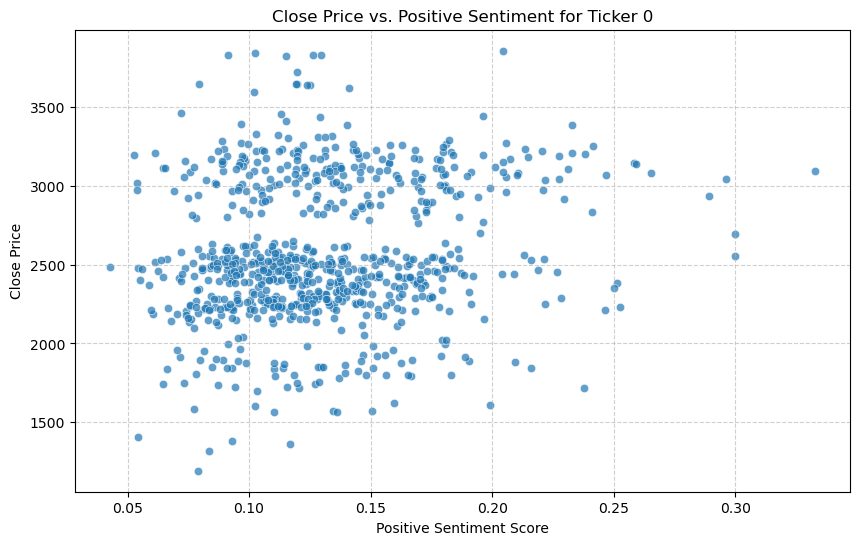

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data for ticker_enumerated == 0
df_filtered = df[df['ticker_enumerated'] == 0]

# Create the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='pos_score', y='Close', data=df_filtered, alpha=0.7)
plt.title('Close Price vs. Positive Sentiment for Ticker 0')
plt.xlabel('Positive Sentiment Score')
plt.ylabel('Close Price')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Feature Engineering: Creating Lagged Features and Target Variable

To predict the 11th day's closing price from 10 days of input, we need to create lagged features for each ticker. This involves shifting the data to create columns representing past values and a target column representing the future value we want to predict.

In [62]:
# Sort the DataFrame by Ticker and Date to ensure correct lagging
df = df.sort_values(by=['Ticker', 'Date'])

# Group by Ticker and create lagged features
features = ['Close', 'pos_score', 'neg_score', 'neu_score', 'Open', 'High', 'Low', 'Volume']

# Create lagged features for the past 10 days
for feature in features:
    for i in range(1, 11):
        df[f'{feature}_lag_{i}'] = df.groupby('Ticker')[feature].shift(i)

# Create the target variable: 'Close' price for the 11th day (shift -1)
df['target_close'] = df.groupby('Ticker')['Close'].shift(-1)

# Drop rows with NaN values resulting from lagging
df_prepared = df.dropna()

print("Lagged features and target variable created successfully.")
print(df_prepared[['Ticker', 'Date', 'Close', 'pos_score', 'Close_lag_1', 'Close_lag_10', 'target_close']].head())

Lagged features and target variable created successfully.
       Ticker        Date    Close  pos_score  Close_lag_1  Close_lag_10  \
480  adanient  2023-01-16  3619.80   0.141085      3721.15       3841.20   
528  adanient  2023-01-17  3639.35   0.123740      3619.80       3830.95   
576  adanient  2023-01-18  3596.70   0.101935      3639.35       3827.05   
624  adanient  2023-01-19  3463.55   0.072113      3596.70       3829.80   
672  adanient  2023-01-20  3456.15   0.113261      3463.55       3824.25   

     target_close  
480       3639.35  
528       3596.70  
576       3463.55  
624       3456.15  
672       3436.35  


In [63]:
print(df_prepared.columns.tolist())
print(df_prepared.shape)

['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'date', 'cleaned_news', 'cleaned_news_len', 'neg_score', 'neu_score', 'pos_score', 'ticker_enumerated', 'ticker_scaled', 'Close_lag_1', 'Close_lag_2', 'Close_lag_3', 'Close_lag_4', 'Close_lag_5', 'Close_lag_6', 'Close_lag_7', 'Close_lag_8', 'Close_lag_9', 'Close_lag_10', 'pos_score_lag_1', 'pos_score_lag_2', 'pos_score_lag_3', 'pos_score_lag_4', 'pos_score_lag_5', 'pos_score_lag_6', 'pos_score_lag_7', 'pos_score_lag_8', 'pos_score_lag_9', 'pos_score_lag_10', 'neg_score_lag_1', 'neg_score_lag_2', 'neg_score_lag_3', 'neg_score_lag_4', 'neg_score_lag_5', 'neg_score_lag_6', 'neg_score_lag_7', 'neg_score_lag_8', 'neg_score_lag_9', 'neg_score_lag_10', 'neu_score_lag_1', 'neu_score_lag_2', 'neu_score_lag_3', 'neu_score_lag_4', 'neu_score_lag_5', 'neu_score_lag_6', 'neu_score_lag_7', 'neu_score_lag_8', 'neu_score_lag_9', 'neu_score_lag_10', 'Open_lag_1', 'Open_lag_2', 'Open_lag_3', 'Open_lag_4', 'Open_lag_5', 'Open_lag_6

### Data Splitting (Train, Validation, Test)

Now we will split the data into training, validation, and test sets. Since this is time-series data, it's crucial to perform the split chronologically to avoid data leakage. We'll use an 80/10/10 ratio for train/validation/test.

In [64]:
import numpy as np

# Determine split points based on time
# First, convert 'Date' column to datetime objects if not already
df_prepared = df_prepared.copy() # Explicitly create a copy to avoid SettingWithCopyWarning
df_prepared['Date'] = pd.to_datetime(df_prepared['Date'])

# Get unique dates and sort them
dates = df_prepared['Date'].unique()
dates = np.sort(dates) # Fixed: Use np.sort for DatetimeArray

# Calculate split indices
total_samples = len(dates)
train_split_idx = int(total_samples * 0.8)
val_split_idx = int(total_samples * 0.9)

train_date_end = dates[train_split_idx - 1]
val_date_end = dates[val_split_idx - 1]

# Split the data chronologically
train_df = df_prepared[df_prepared['Date'] <= train_date_end]
val_df = df_prepared[(df_prepared['Date'] > train_date_end) & (df_prepared['Date'] <= val_date_end)]
test_df = df_prepared[df_prepared['Date'] > val_date_end]

print(f"Training data shape: {train_df.shape}")
print(f"Validation data shape: {val_df.shape}")
print(f"Test data shape: {test_df.shape}")

print("Data split into training, validation, and test sets successfully.")

Training data shape: (30005, 97)
Validation data shape: (3779, 97)
Test data shape: (3847, 97)
Data split into training, validation, and test sets successfully.


In [65]:
# Define the features (X) and target (y)
feature_cols = [
    'Open', 'High', 'Low', 'Close', 'Volume',
    'neg_score', 'neu_score', 'pos_score',
    'ticker_scaled'
]

# Add all lagged features (lag 1 to 10 for each of the original features)
lag_features_base = ['Close', 'pos_score', 'neg_score', 'neu_score', 'Open', 'High', 'Low', 'Volume']
for base_feature in lag_features_base:
    for i in range(1, 11):
        feature_cols.append(f'{base_feature}_lag_{i}')

target_col = 'target_close'

# Prepare X and y for train, validation, and test sets
X_train = train_df[feature_cols].copy()
y_train = train_df[target_col].copy()

X_val = val_df[feature_cols].copy()
y_val = val_df[target_col].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].copy()

print("Feature and target sets created successfully.")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

Feature and target sets created successfully.
X_train shape: (30005, 89), y_train shape: (30005,)
X_val shape: (3779, 89), y_val shape: (3779,)
X_test shape: (3847, 89), y_test shape: (3847,)


In [66]:
from sklearn.preprocessing import MinMaxScaler

# Identify numerical columns to be scaled (excluding sentiments and ticker_scaled as they are already in range 0-1)
columns_to_scale = [
    'Open', 'High', 'Low', 'Close', 'Volume',
    'Close_lag_1', 'Close_lag_2', 'Close_lag_3', 'Close_lag_4', 'Close_lag_5', 'Close_lag_6', 'Close_lag_7', 'Close_lag_8', 'Close_lag_9', 'Close_lag_10',
    'Open_lag_1', 'Open_lag_2', 'Open_lag_3', 'Open_lag_4', 'Open_lag_5', 'Open_lag_6', 'Open_lag_7', 'Open_lag_8', 'Open_lag_9', 'Open_lag_10',
    'High_lag_1', 'High_lag_2', 'High_lag_3', 'High_lag_4', 'High_lag_5', 'High_lag_6', 'High_lag_7', 'High_lag_8', 'High_lag_9', 'High_lag_10',
    'Low_lag_1', 'Low_lag_2', 'Low_lag_3', 'Low_lag_4', 'Low_lag_5', 'Low_lag_6', 'Low_lag_7', 'Low_lag_8', 'Low_lag_9', 'Low_lag_10',
    'Volume_lag_1', 'Volume_lag_2', 'Volume_lag_3', 'Volume_lag_4', 'Volume_lag_5', 'Volume_lag_6', 'Volume_lag_7', 'Volume_lag_8', 'Volume_lag_9', 'Volume_lag_10'
]

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Fit the scaler on the training data for the specified columns and transform
X_train[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])

# Transform the validation and test data using the scaler fitted on the training data
X_val[columns_to_scale] = scaler.transform(X_val[columns_to_scale])
X_test[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

print("Selected numerical features scaled successfully to range 0-1.")
print("X_train (first 5 rows after scaling):")
display(X_train[columns_to_scale].head())
print("X_test (first 5 rows after scaling):")
display(X_test[columns_to_scale].head())

Selected numerical features scaled successfully to range 0-1.
X_train (first 5 rows after scaling):


,Open,High,Low,Close,Volume,Close_lag_1,Close_lag_2,Close_lag_3,Close_lag_4,Close_lag_5,...,Volume_lag_1,Volume_lag_2,Volume_lag_3,Volume_lag_4,Volume_lag_5,Volume_lag_6,Volume_lag_7,Volume_lag_8,Volume_lag_9,Volume_lag_10
480,0.275165,0.270800,0.268755,0.265666,0.003986,0.273202,0.267703,0.266856,0.267681,0.283177,...,0.002919,0.002566,0.004762,0.007690,0.001613,0.001951,0.002132,0.002199,0.001711,0.001974
528,0.267671,0.264172,0.265746,0.267120,0.003568,0.265666,0.273202,0.267703,0.266856,0.267681,...,0.003986,0.002919,0.002566,0.004762,0.007690,0.001613,0.001951,0.002132,0.002199,0.001711
576,0.269769,0.264055,0.263244,0.263948,0.007811,0.267120,0.265666,0.273202,0.267703,0.266856,...,0.003568,0.003986,0.002919,0.002566,0.004762,0.007690,0.001613,0.001951,0.002132,0.002199
624,0.256431,0.255963,0.255656,0.254048,0.007905,0.263948,0.267120,0.265666,0.273202,0.267703,...,0.007811,0.003568,0.003986,0.002919,0.002566,0.004762,0.007690,0.001613,0.001951,0.002132
672,0.254933,0.251536,0.256733,0.253498,0.003230,0.254048,0.263948,0.267120,0.265666,0.273202,...,0.007905,0.007811,0.003568,0.003986,0.002919,0.002566,0.004762,0.007690,0.001613,0.001951


X_test (first 5 rows after scaling):


,Open,High,Low,Close,Volume,Close_lag_1,Close_lag_2,Close_lag_3,Close_lag_4,Close_lag_5,...,Volume_lag_1,Volume_lag_2,Volume_lag_3,Volume_lag_4,Volume_lag_5,Volume_lag_6,Volume_lag_7,Volume_lag_8,Volume_lag_9,Volume_lag_10
34284,0.169377,0.166276,0.169879,0.167408,0.001235,0.172690,0.168593,0.176438,0.179947,0.180988,...,0.004775,0.004231,0.004433,0.001564,0.001815,0.001675,0.003265,0.001341,0.001022,0.001013
34334,0.168439,0.165629,0.168010,0.167127,0.001399,0.167408,0.172690,0.168593,0.176438,0.179947,...,0.001235,0.004775,0.004231,0.004433,0.001564,0.001815,0.001675,0.003265,0.001341,0.001022
34384,0.169602,0.175486,0.169659,0.175612,0.014748,0.167127,0.167408,0.172690,0.168593,0.176438,...,0.001399,0.001235,0.004775,0.004231,0.004433,0.001564,0.001815,0.001675,0.003265,0.001341
34434,0.178174,0.176019,0.177507,0.175878,0.005970,0.175612,0.167127,0.167408,0.172690,0.168593,...,0.014748,0.001399,0.001235,0.004775,0.004231,0.004433,0.001564,0.001815,0.001675,0.003265
34484,0.178029,0.178060,0.178452,0.177940,0.009919,0.175878,0.175612,0.167127,0.167408,0.172690,...,0.005970,0.014748,0.001399,0.001235,0.004775,0.004231,0.004433,0.001564,0.001815,0.001675


### LSTM Model Training

To train an LSTM model, we first need to reshape our input data `X` into a 3D array: `(samples, timesteps, features_per_timestep)`.

We have identified 8 time-varying features (`Close`, `pos_window`, `neg_window`, `neu_window`, `Open`, `High`, `Low`, `Volume`) and an 11-day window (current day + 10 lags). Thus, `timesteps` will be 11 and `features_per_timestep` will be 8. The `ticker_scaled` feature will be excluded from the sequential input for this initial model setup.

In [67]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Define the base features that were lagged and will form our timesteps
features_base = ['Close', 'pos_score', 'neg_score', 'neu_score', 'Open', 'High', 'Low', 'Volume']
N_TIMESTEPS = 11  # Current day + 10 lagged days
N_FEATURES_PER_TIMESTEP = len(features_base)  # 8 features

# List to hold the reordered feature columns for LSTM input
lstm_feature_columns = []

# Add features from t-10 down to t-1 (lagged features)
for lag in range(10, 0, -1):
    for feature in features_base:
        lstm_feature_columns.append(f'{feature}_lag_{lag}')

# Add current day's features
for feature in features_base:
    lstm_feature_columns.append(feature)

# Select these specific columns from the X datasets and convert to numpy arrays
X_train_lstm = X_train[lstm_feature_columns].values
X_val_lstm   = X_val[lstm_feature_columns].values
X_test_lstm  = X_test[lstm_feature_columns].values

# Extract the 'ticker_scaled' feature separately
X_train_ticker = X_train['ticker_scaled'].values
X_val_ticker   = X_val['ticker_scaled'].values
X_test_ticker  = X_test['ticker_scaled'].values

# Reshape the data to (samples, timesteps, features_per_timestep)
X_train_reshaped = X_train_lstm.reshape((X_train_lstm.shape[0], N_TIMESTEPS, N_FEATURES_PER_TIMESTEP))
X_val_reshaped   = X_val_lstm.reshape((X_val_lstm.shape[0], N_TIMESTEPS, N_FEATURES_PER_TIMESTEP))
X_test_reshaped  = X_test_lstm.reshape((X_test_lstm.shape[0], N_TIMESTEPS, N_FEATURES_PER_TIMESTEP))

print("Data reshaped for LSTM model successfully.")
print(f"X_train_reshaped shape: {X_train_reshaped.shape}")
print(f"X_val_reshaped shape  : {X_val_reshaped.shape}")
print(f"X_test_reshaped shape : {X_test_reshaped.shape}")

Data reshaped for LSTM model successfully.
X_train_reshaped shape: (30005, 11, 8)
X_val_reshaped shape  : (3779, 11, 8)
X_test_reshaped shape : (3847, 11, 8)


### LSTM Model Definition

In [68]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Define the base features (including ticker_scaled as a static feature repeated across timesteps)
features_base = ['Close', 'pos_score', 'neg_score', 'neu_score', 'Open', 'High', 'Low', 'Volume', 'ticker_scaled']
N_TIMESTEPS = 11  # Current day + 10 lagged days
N_FEATURES_PER_TIMESTEP = len(features_base)  # 9 features

# List to hold the reordered feature columns for LSTM input
lstm_feature_columns = []

# Add features from t-10 down to t-1 (lagged features)
for lag in range(10, 0, -1):
    for feature in features_base:
        if feature == 'ticker_scaled':  # ticker_scaled has no lags; repeat the same column
            lstm_feature_columns.append(feature)
        else:
            lstm_feature_columns.append(f'{feature}_lag_{lag}')

# Add current day's features
for feature in features_base:
    lstm_feature_columns.append(feature)

# Select these specific columns from the X datasets and convert to numpy arrays
X_train_lstm = X_train[lstm_feature_columns].values
X_val_lstm   = X_val[lstm_feature_columns].values
X_test_lstm  = X_test[lstm_feature_columns].values

# Reshape the data to (samples, timesteps, features_per_timestep)
X_train_reshaped = X_train_lstm.reshape((X_train_lstm.shape[0], N_TIMESTEPS, N_FEATURES_PER_TIMESTEP))
X_val_reshaped   = X_val_lstm.reshape((X_val_lstm.shape[0], N_TIMESTEPS, N_FEATURES_PER_TIMESTEP))
X_test_reshaped  = X_test_lstm.reshape((X_test_lstm.shape[0], N_TIMESTEPS, N_FEATURES_PER_TIMESTEP))

print("Data reshaped for LSTM model successfully.")
print(f"X_train_reshaped shape: {X_train_reshaped.shape}")
print(f"X_val_reshaped shape  : {X_val_reshaped.shape}")
print(f"X_test_reshaped shape : {X_test_reshaped.shape}")

Data reshaped for LSTM model successfully.
X_train_reshaped shape: (30005, 11, 9)
X_val_reshaped shape  : (3779, 11, 9)
X_test_reshaped shape : (3847, 11, 9)


In [69]:

import os, random
import numpy as np
import tensorflow as tf

# ── Reproducibility (must be set BEFORE building the model) ──
SEED = 32
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f"Random seeds set to {SEED}")

# ── GPU memory growth (prevents TF from grabbing all 4 GB at once) ──
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"✓ {len(gpus)} GPU(s) detected: {[g.name for g in gpus]}")
    print(f"  TF version : {tf.__version__}")

    # Keep float32 precision to match HPT_10days tuning conditions
    # (mixed_float16 removed — it changes numerical behavior vs the HP search)
    print("✓ Using float32 precision (matching HP tuning conditions)")
else:
    print("⚠ No GPU found — running on CPU")

# ── IMPORTANT: HP were tuned with BATCH_SIZE=64 (HPT_10days ran on CPU).
#    Using a different batch size changes training dynamics and degrades results.
#    Keep batch_size=64 to match the tuning conditions. ──
BATCH_SIZE = 64
print(f"Batch size : {BATCH_SIZE}")


Random seeds set to 32
✓ 1 GPU(s) detected: ['/physical_device:GPU:0']
  TF version : 2.21.0
✓ Using float32 precision (matching HP tuning conditions)
Batch size : 64


In [70]:

from tensorflow import keras
from tensorflow.keras import layers

# ══════════════════════════════════════════════════════════════════════
#  Best Hyperparameters (from Bayesian Optimization in HPT_10days.ipynb)
# ══════════════════════════════════════════════════════════════════════
BEST_HP = {
    'lstm_units_1':  64,
    'lstm_units_2':  32,
    'dropout_rate':  0.3,
    'dense_units':   64,
    'learning_rate': 0.0021,
}

print("Best HP from Bayesian Optimization (HPT_10days.ipynb):")
for k, v in BEST_HP.items():
    print(f"  {k:20s} = {v}")

# ── LSTM Model built with tuned hyperparameters ──
lstm_input = layers.Input(shape=(N_TIMESTEPS, N_FEATURES_PER_TIMESTEP), name='lstm_input')

x = layers.LSTM(units=BEST_HP['lstm_units_1'], return_sequences=True, name='lstm_1')(lstm_input)
x = layers.Dropout(BEST_HP['dropout_rate'])(x)
x = layers.LSTM(units=BEST_HP['lstm_units_2'], name='lstm_2')(x)
x = layers.Dropout(BEST_HP['dropout_rate'])(x)

x = layers.Dense(BEST_HP['dense_units'], activation='relu')(x)
output_layer = layers.Dense(units=1, dtype='float32', name='output')(x)

model = keras.Model(inputs=lstm_input, outputs=output_layer)
model.summary()


Best HP from Bayesian Optimization (HPT_10days.ipynb):
  lstm_units_1         = 64
  lstm_units_2         = 32
  dropout_rate         = 0.3
  dense_units          = 64
  learning_rate        = 0.0021


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_input (InputLayer)         │ (None, 11, 9)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 11, 64)         │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 11, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,537 (131.00 KB)

 Trainable params: 33,537 (131.00 KB)

 Non-trainable params: 0 (0.00 B)

### Compile the LSTM Model

In [71]:

# Seeds were already set in the GPU/TF setup cell above (SEED=32).
# This cell is kept as a checkpoint to verify variables are still in scope.
print(f"SEED={SEED}, BATCH_SIZE={BATCH_SIZE}")
print(f"Training samples : {X_train_reshaped.shape[0]:,}")
print(f"Validation samples: {X_val_reshaped.shape[0]:,}")
print(f"Test samples     : {X_test_reshaped.shape[0]:,}")


SEED=32, BATCH_SIZE=64
Training samples : 30,005
Validation samples: 3,779
Test samples     : 3,847


In [72]:

# Compile with the best learning rate from HPT_10days Bayesian Optimization
optimizer = tf.keras.optimizers.Adam(learning_rate=BEST_HP['learning_rate'])

model.compile(
    optimizer=optimizer,
    loss='mse',
    metrics=['mae', 'root_mean_squared_error', 'mean_absolute_percentage_error']
)
print(f"Model compiled  |  lr = {BEST_HP['learning_rate']:.4f}")


Model compiled  |  lr = 0.0021


In [73]:

import os

# ── tf.data pipeline: prefetch keeps GPU fed while CPU prepares next batch ──
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_train_reshaped, y_train.values.astype('float32')))
    .shuffle(buffer_size=len(X_train_reshaped), seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
val_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_val_reshaped, y_val.values.astype('float32')))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# ── Callbacks ──
os.makedirs('checkpoints', exist_ok=True)
callbacks = [
    # Stop early if val_loss doesn't improve for 15 epochs (saves time)
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=15, restore_best_weights=True, verbose=1
    ),
    # Halve LR when plateau detected → better convergence
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1
    ),
    # Save best checkpoint to disk
    tf.keras.callbacks.ModelCheckpoint(
        filepath='checkpoints/best_lstm.keras',
        monitor='val_loss', save_best_only=True, verbose=0
    ),
]

# ── Train ──
history = model.fit(
    train_ds,
    epochs=120,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=1,
)
print("\n✓ Training complete.")
print(f"  Best val_loss : {min(history.history['val_loss']):.4f}")
print(f"  Epochs run    : {len(history.history['loss'])}")


Epoch 1/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 7868211.5000 - mae: 1646.3624 - mean_absolute_percentage_error: 107.6018 - root_mean_squared_error: 2805.0332 - val_loss: 9579688.0000 - val_mae: 1729.9137 - val_mean_absolute_percentage_error: 141.6451 - val_root_mean_squared_error: 3095.1069 - learning_rate: 0.0021
Epoch 2/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 4995256.0000 - mae: 1252.6831 - mean_absolute_percentage_error: 145.3797 - root_mean_squared_error: 2235.0068 - val_loss: 5220689.5000 - val_mae: 769.7552 - val_mean_absolute_percentage_error: 15.0896 - val_root_mean_squared_error: 2284.8828 - learning_rate: 0.0021
Epoch 3/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1435577.7500 - mae: 440.9023 - mean_absolute_percentage_error: 19.7675 - root_mean_squared_error: 1198.1560 - val_loss: 1692313.5000 - val_mae: 326.7603 - val_mean_absolute_percentage_error: 6.1316 - val_root_mean_squared_error: 1300.8895 - learning_rate: 0.0021
Epoch 4/120
469/469 

In [74]:
# Evaluate the model on the test set
loss, mae, rmse, mape = model.evaluate(X_test_reshaped, y_test, verbose=0)

print(f"Test Loss (MSE): {loss}")
print(f"Test MAE: {mae}")
print(f"Test RMSE: {rmse}")
print(f"Test MAPE: {mape}")

Test Loss (MSE): 30766.908203125
Test MAE: 60.12369918823242
Test RMSE: 175.4049835205078
Test MAPE: 2.988088369369507


In [75]:
# Make predictions on the test set
predictions = model.predict(X_test_reshaped)

# Reshape y_test for plotting if it's a Series
y_test_np = y_test.values.reshape(-1, 1)

print("Predictions made successfully.")
print(f"Predictions shape: {predictions.shape}")
print(f"Actual values shape: {y_test_np.shape}")

121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predictions made successfully.
Predictions shape: (3847, 1)
Actual values shape: (3847, 1)


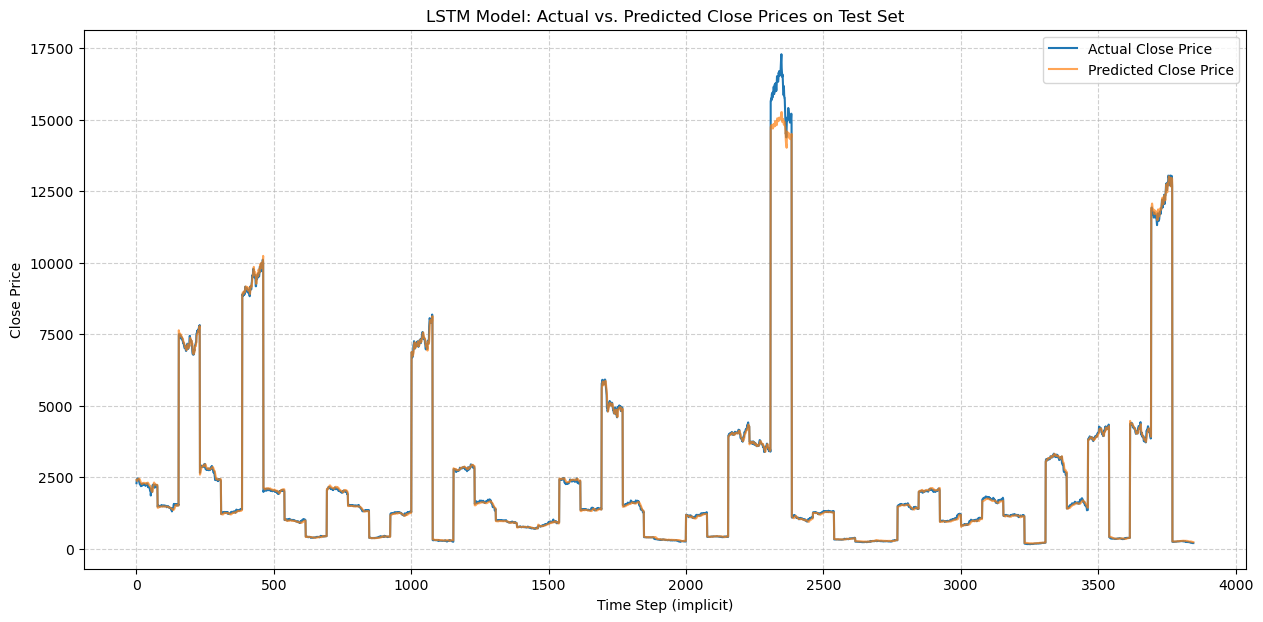

In [76]:
import matplotlib.pyplot as plt

# Create a DataFrame for easier plotting
plot_df = pd.DataFrame({
    'Actual Close': y_test_np.flatten(),
    'Predicted Close': predictions.flatten()
})

plt.figure(figsize=(15, 7))
plt.plot(plot_df['Actual Close'], label='Actual Close Price')
plt.plot(plot_df['Predicted Close'], label='Predicted Close Price', alpha=0.7)
plt.title('LSTM Model: Actual vs. Predicted Close Prices on Test Set')
plt.xlabel('Time Step (implicit)')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [77]:
display(plot_df.head(10))

,Actual Close,Predicted Close
0,2294.58,2410.497314
1,2408.69,2383.411133
2,2412.27,2372.090576
3,2440.00,2379.227295
4,2462.00,2398.079102
5,2436.80,2419.249023
6,2433.10,2433.420166
7,2446.10,2440.965576
8,2422.30,2452.376465
9,2399.20,2453.381104


In [78]:
model.save('lstm_stock_predictor_norm_2lstm_tsip.keras')
print("Trained model saved as 'lstm_stock_predictor.keras'")

Trained model saved as 'lstm_stock_predictor.keras'


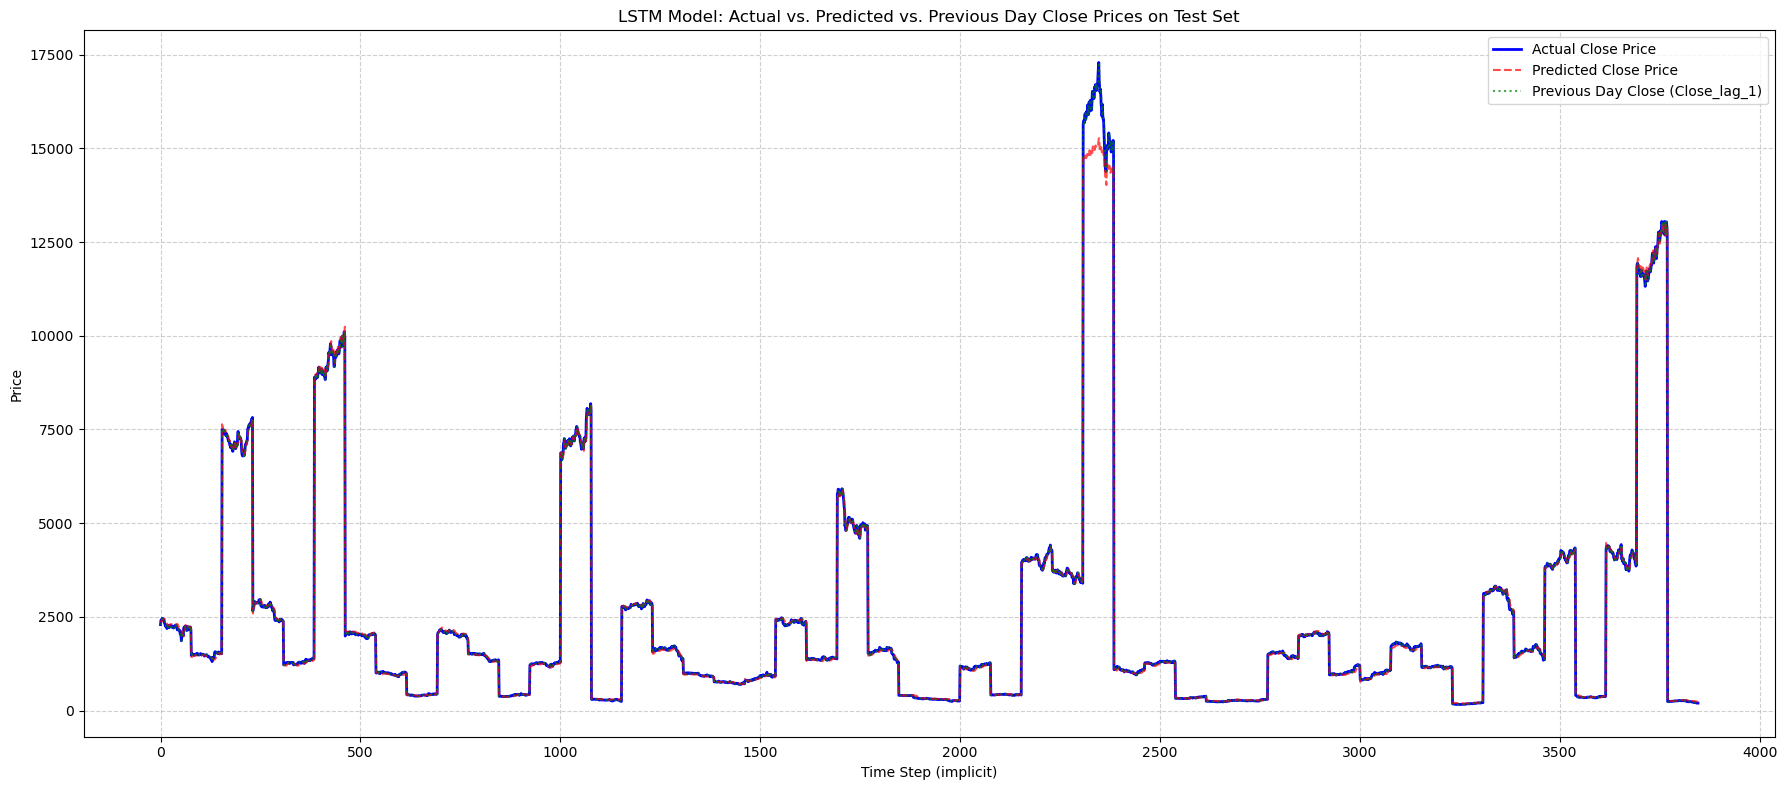

,Actual Close,Predicted Close,Close_lag_1
0,2294.58,2410.497314,2298.36
1,2408.69,2383.411133,2294.58
2,2412.27,2372.090576,2408.69
3,2440.00,2379.227295,2412.27
4,2462.00,2398.079102,2440.00


In [79]:
import matplotlib.pyplot as plt
import pandas as pd

# To inverse transform 'Close_lag_1', we need the full 'columns_to_scale' context from X_test
# First, ensure X_test is a DataFrame (it already is)

# Create a temporary DataFrame with all scaled columns that were used for fitting the scaler
temp_X_test_scaled_for_inverse = X_test[columns_to_scale]

# Inverse transform these columns. This will return a numpy array in the original scale.
original_scale_features = scaler.inverse_transform(temp_X_test_scaled_for_inverse)

# Convert back to DataFrame to easily select the 'Close_lag_1' column, preserving index for potential merges
original_scale_features_df = pd.DataFrame(original_scale_features, columns=columns_to_scale, index=X_test.index)

# Now, extract the inverse-transformed 'Close_lag_1'
inverse_transformed_close_lag_1 = original_scale_features_df['Close'].values.flatten()

# Combine the relevant data into a single DataFrame for plotting
combined_plot_df = pd.DataFrame({
    'Actual Close': y_test_np.flatten(),
    'Predicted Close': predictions.flatten(),
    'Close_lag_1': inverse_transformed_close_lag_1
})

plt.figure(figsize=(18, 8))
plt.plot(combined_plot_df['Actual Close'], label='Actual Close Price', color='blue', linewidth=2)
plt.plot(combined_plot_df['Predicted Close'], label='Predicted Close Price', color='red', linestyle='--', alpha=0.7)
plt.plot(combined_plot_df['Close_lag_1'], label='Previous Day Close (Close_lag_1)', color='green', linestyle=':', alpha=0.7)
plt.title('LSTM Model: Actual vs. Predicted vs. Previous Day Close Prices on Test Set')
plt.xlabel('Time Step (implicit)')
plt.ylabel('Price')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

display(combined_plot_df.head())

MAPE for ALL tickers (sorted best → worst):


,Ticker,MAPE (%)
0,ultracemco,1.032641
1,apollohosp,1.080328
2,bajaj-auto,1.088869
3,grasim,1.089682
4,lt,1.141959
5,titan,1.142957
6,eichermot,1.251004
7,m&m,1.262892
8,sbilife,1.637276
9,indigo,1.652553



Top 5 tickers (lowest MAPE): ['ultracemco', 'apollohosp', 'bajaj-auto', 'grasim', 'lt']


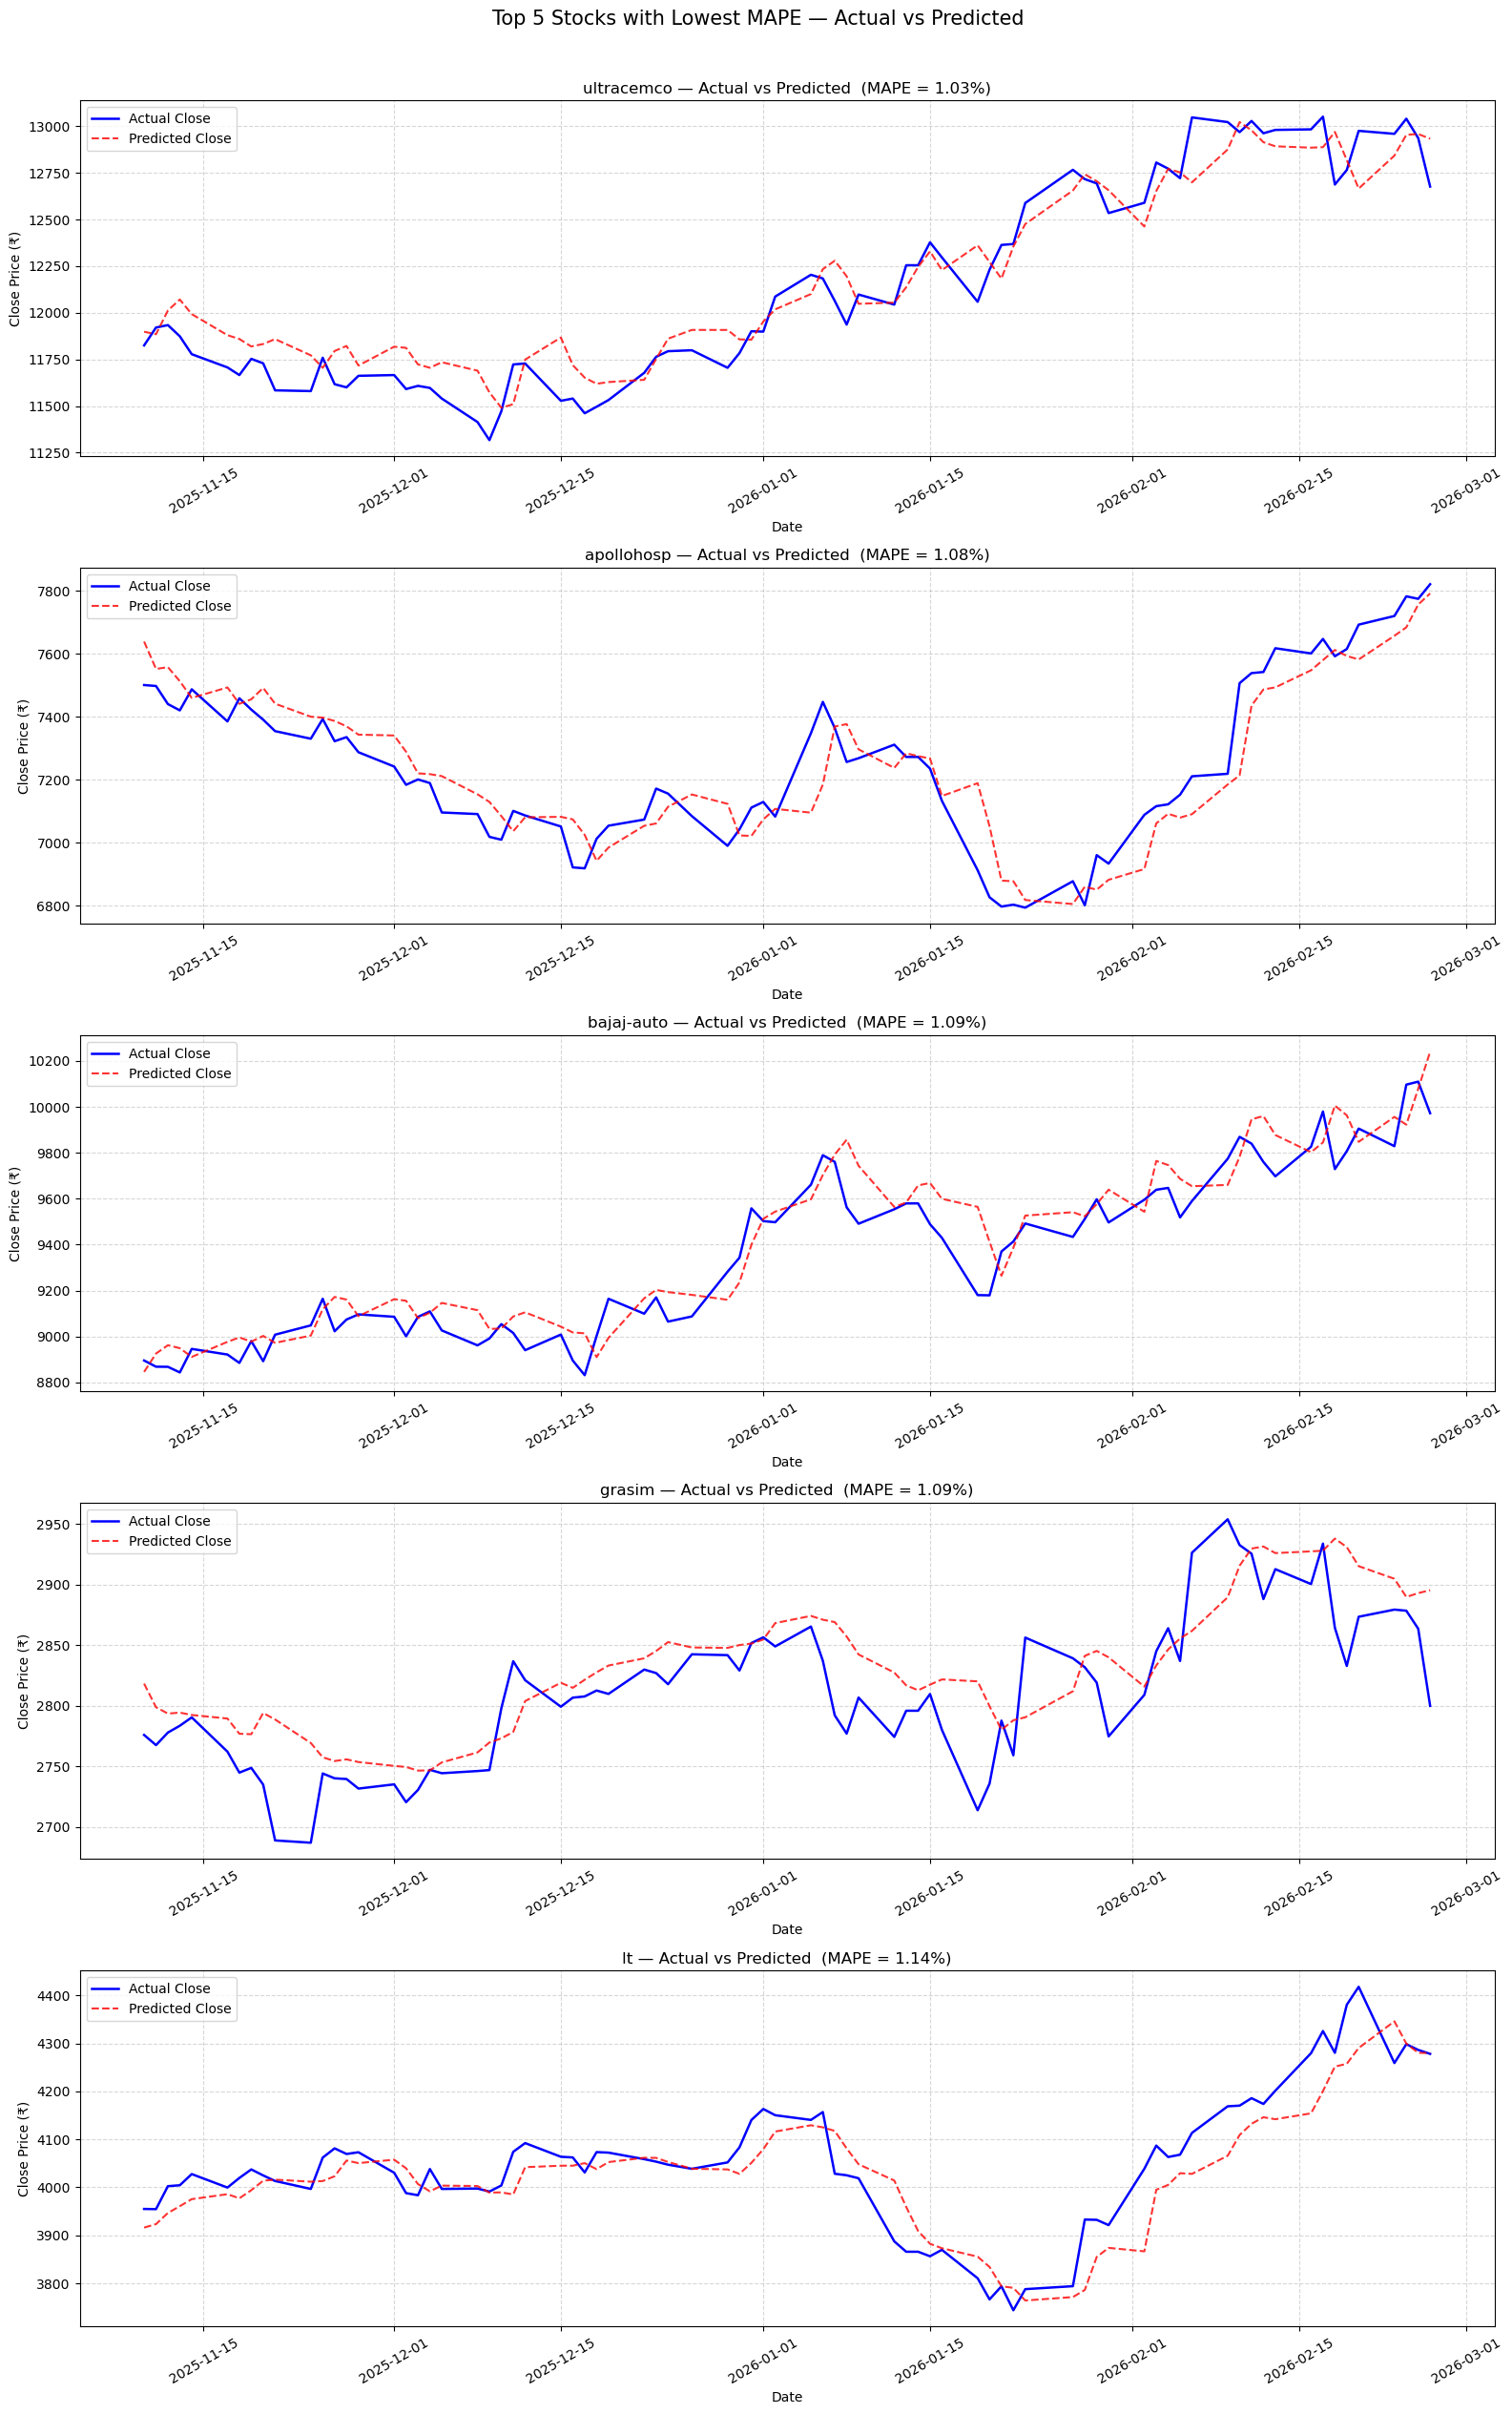


Metrics for top 5 (lowest MAPE):
  ultracemco            MAPE =   1.03%   MAE =   124.38   RMSE =   153.04
  apollohosp            MAPE =   1.08%   MAE =    78.03   RMSE =    99.95
  bajaj-auto            MAPE =   1.09%   MAE =   102.08   RMSE =   127.42
  grasim                MAPE =   1.09%   MAE =    30.49   RMSE =    40.12
  lt                    MAPE =   1.14%   MAE =    46.48   RMSE =    60.64


In [80]:

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ══════════════════════════════════════════════════════════════════════
#  Per-Ticker MAPE → Plot 5 Stocks with Lowest MAPE
# ══════════════════════════════════════════════════════════════════════

# test_df retains Ticker & Date columns and its row order matches y_test / predictions
ticker_series = test_df['Ticker'].values
date_series   = pd.to_datetime(test_df['Date'].values)

per_ticker_df = pd.DataFrame({
    'Ticker':          ticker_series,
    'Date':            date_series,
    'Actual Close':    y_test_np.flatten(),
    'Predicted Close': predictions.flatten(),
})

# ── Calculate MAPE for each ticker ──
def ticker_mape(grp):
    return np.mean(np.abs((grp['Actual Close'] - grp['Predicted Close']) / grp['Actual Close'])) * 100

mape_per_ticker = per_ticker_df.groupby('Ticker').apply(ticker_mape).rename('MAPE (%)')
mape_df = mape_per_ticker.sort_values().reset_index()
mape_df.columns = ['Ticker', 'MAPE (%)']

print("MAPE for ALL tickers (sorted best → worst):")
display(mape_df)

# ── Top 5 tickers with lowest MAPE ──
best5 = mape_df.head(5)['Ticker'].tolist()
print(f"\nTop 5 tickers (lowest MAPE): {best5}")

# ── Plot each ticker on its own subplot ──
fig, axes = plt.subplots(5, 1, figsize=(16, 25), sharex=False)

for ax, ticker in zip(axes, best5):
    tk_df = per_ticker_df[per_ticker_df['Ticker'] == ticker].sort_values('Date').reset_index(drop=True)
    tk_mape = mape_df[mape_df['Ticker'] == ticker]['MAPE (%)'].values[0]

    ax.plot(tk_df['Date'], tk_df['Actual Close'],
            label='Actual Close', color='blue', linewidth=1.8)
    ax.plot(tk_df['Date'], tk_df['Predicted Close'],
            label='Predicted Close', color='red', linestyle='--', alpha=0.8)
    ax.set_title(f'{ticker} — Actual vs Predicted  (MAPE = {tk_mape:.2f}%)')
    ax.set_xlabel('Date')
    ax.set_ylabel('Close Price (₹)')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Top 5 Stocks with Lowest MAPE — Actual vs Predicted', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

# ── Summary table for best 5 ──
print("\nMetrics for top 5 (lowest MAPE):")
for ticker in best5:
    tk = per_ticker_df[per_ticker_df['Ticker'] == ticker]
    mae  = np.mean(np.abs(tk['Actual Close'] - tk['Predicted Close']))
    rmse = np.sqrt(np.mean((tk['Actual Close'] - tk['Predicted Close'])**2))
    mape_val = mape_df[mape_df['Ticker'] == ticker]['MAPE (%)'].values[0]
    print(f"  {ticker:20s}  MAPE = {mape_val:6.2f}%   MAE = {mae:8.2f}   RMSE = {rmse:8.2f}")
